# 03. Exploratory Data Analysis - Home Loan Approval Prediction

**Objective
Explore the cleaned data to understand patterns, relationships, and insights that can help predict loan approval.

**Main Goals
- Analyze the target variable more deeply
- Examine numerical and categorical features
- Understand relationships between features and Loan_Status
- Generate clear observations for modeling.
    

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# Load the cleaned data
train = pd.read_csv('../data/processed/train_cleaned.csv')
test = pd.read_csv('../data/processed/test_cleaned.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Cleaned data loaded successfully.")

Train shape: (614, 13)
Test shape: (367, 12)
Cleaned data loaded successfully.


=== Loan Status Distribution ===
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Percentage:
Loan_Status
Y    68.7
N    31.3
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_6092\69461694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='Loan_Status', palette='Set2')


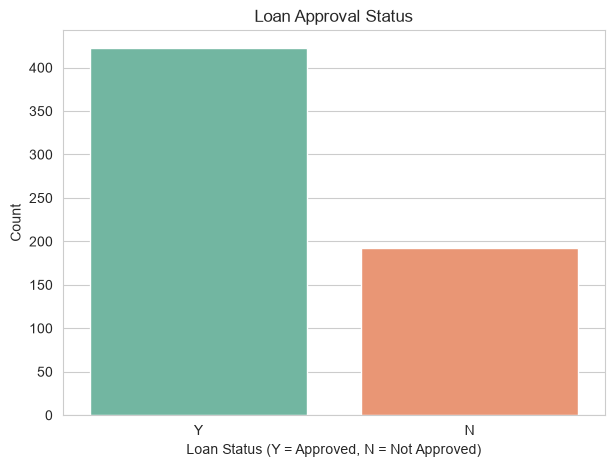

In [8]:
print("=== Loan Status Distribution ===")
print(train['Loan_Status'].value_counts())
print("\nPercentage:")
print(train['Loan_Status'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(data=train, x='Loan_Status', palette='Set2')
plt.title('Loan Approval Status')
plt.xlabel('Loan Status (Y = Approved, N = Not Approved)')
plt.ylabel('Count')
plt.show()

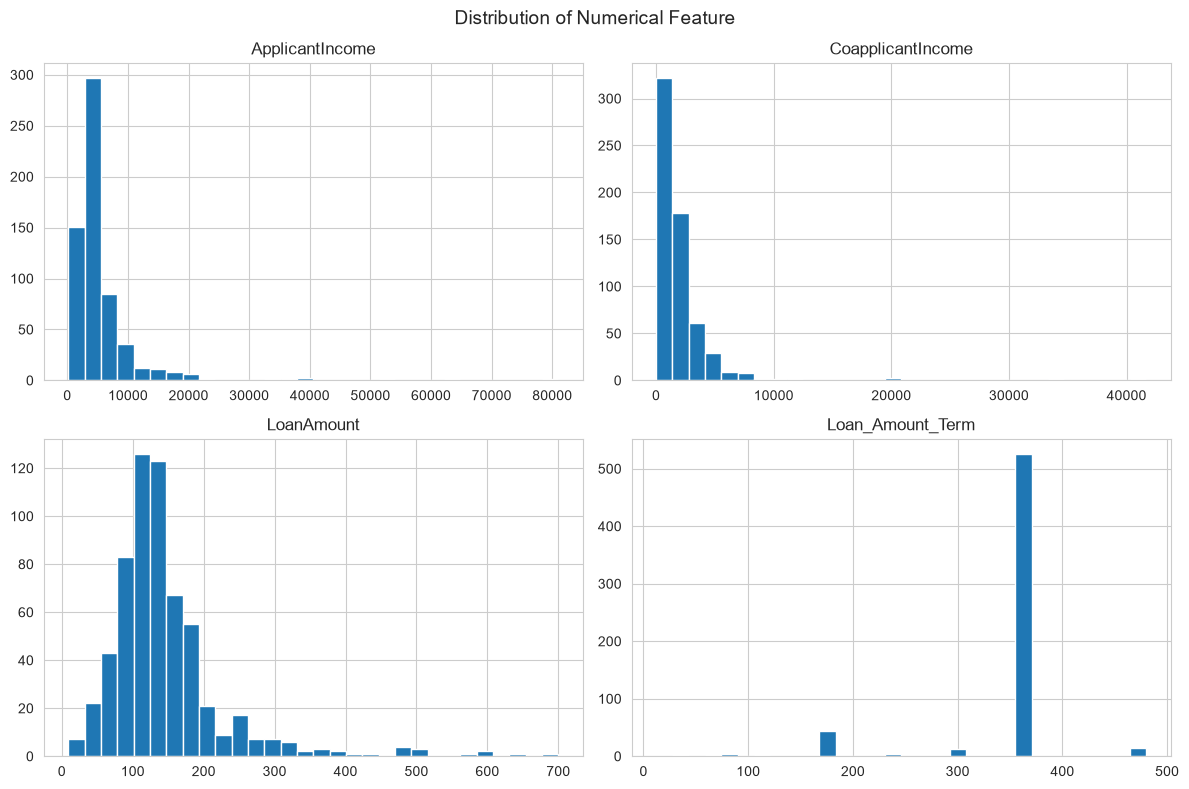

In [10]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

train[numerical_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribution of Numerical Feature', fontsize=14)
plt.tight_layout()
plt.show()

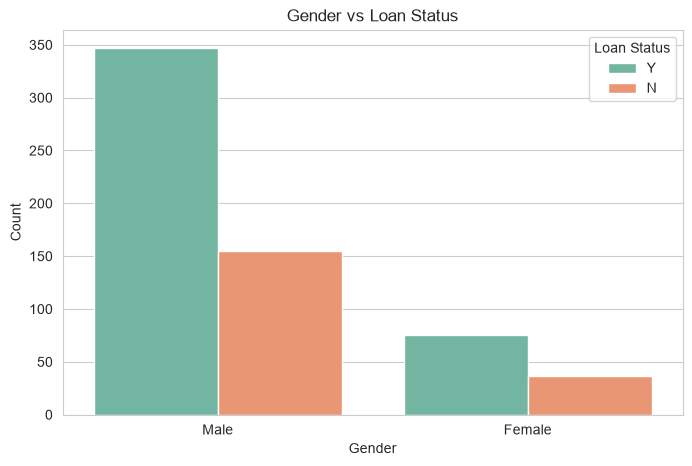

Loan_Status     N     Y
Gender                 
Female       33.0  67.0
Male         30.9  69.1

--------------------------------------------------



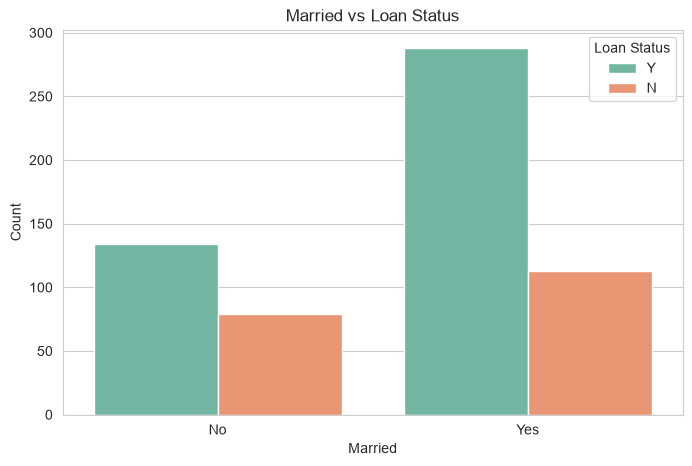

Loan_Status     N     Y
Married                
No           37.1  62.9
Yes          28.2  71.8

--------------------------------------------------



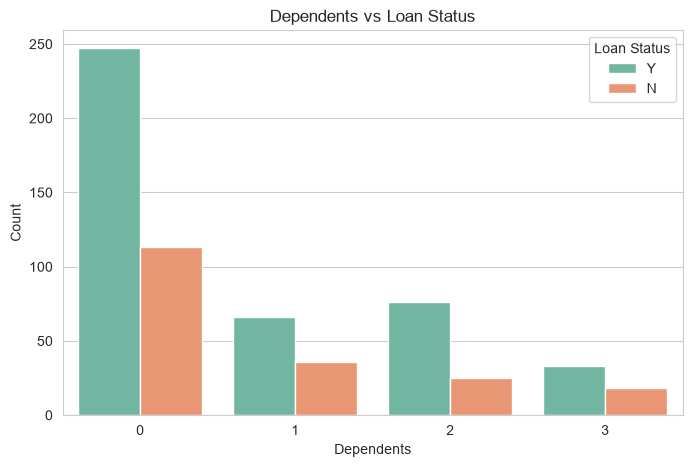

Loan_Status     N     Y
Dependents             
0            31.4  68.6
1            35.3  64.7
2            24.8  75.2
3            35.3  64.7

--------------------------------------------------



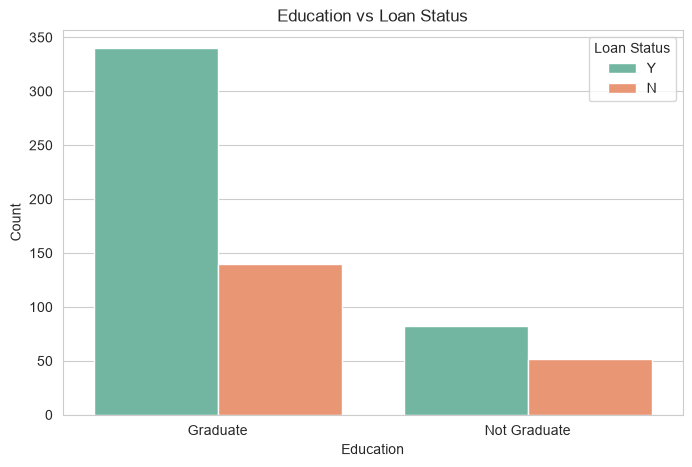

Loan_Status      N     Y
Education               
Graduate      29.2  70.8
Not Graduate  38.8  61.2

--------------------------------------------------



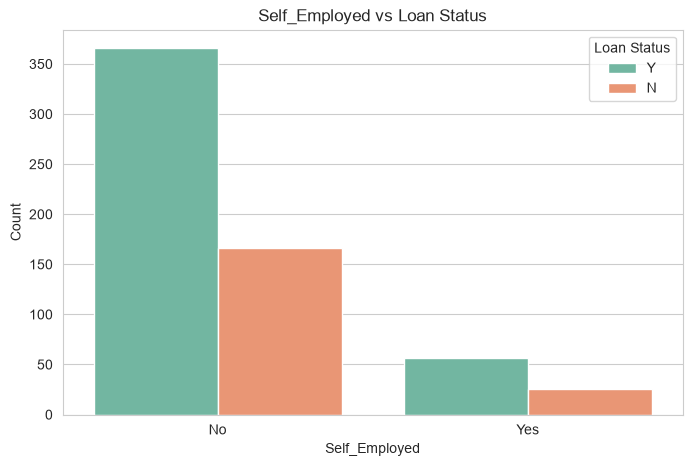

Loan_Status       N     Y
Self_Employed            
No             31.2  68.8
Yes            31.7  68.3

--------------------------------------------------



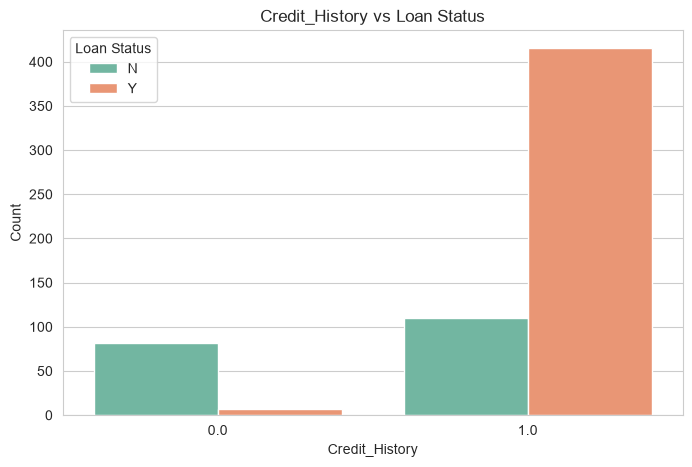

Loan_Status        N     Y
Credit_History            
0.0             92.1   7.9
1.0             21.0  79.0

--------------------------------------------------



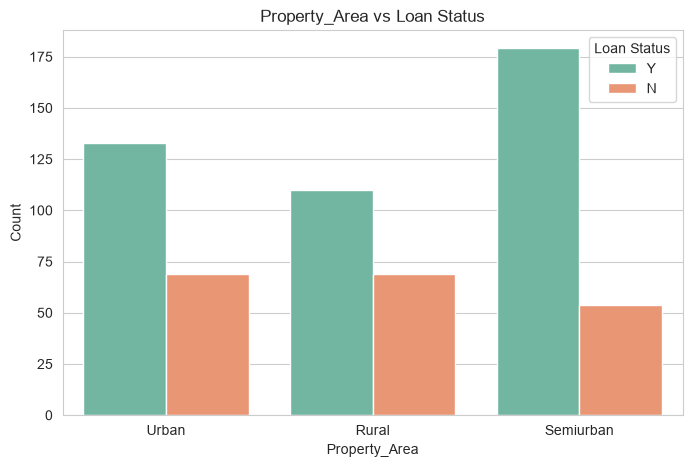

Loan_Status       N     Y
Property_Area            
Rural          38.5  61.5
Semiurban      23.2  76.8
Urban          34.2  65.8

--------------------------------------------------



In [11]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=train, x=col, hue='Loan_Status', palette='Set2')
    plt.title(f'{col} vs Loan Status')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.legend(title='Loan Status')
    plt.show()

    # Show Approval Rate
    print(train.groupby(col)
    ['Loan_Status'].value_counts(normalize=True).unstack().round(3) * 100)
    print("\n" + "-"*50 + "\n")

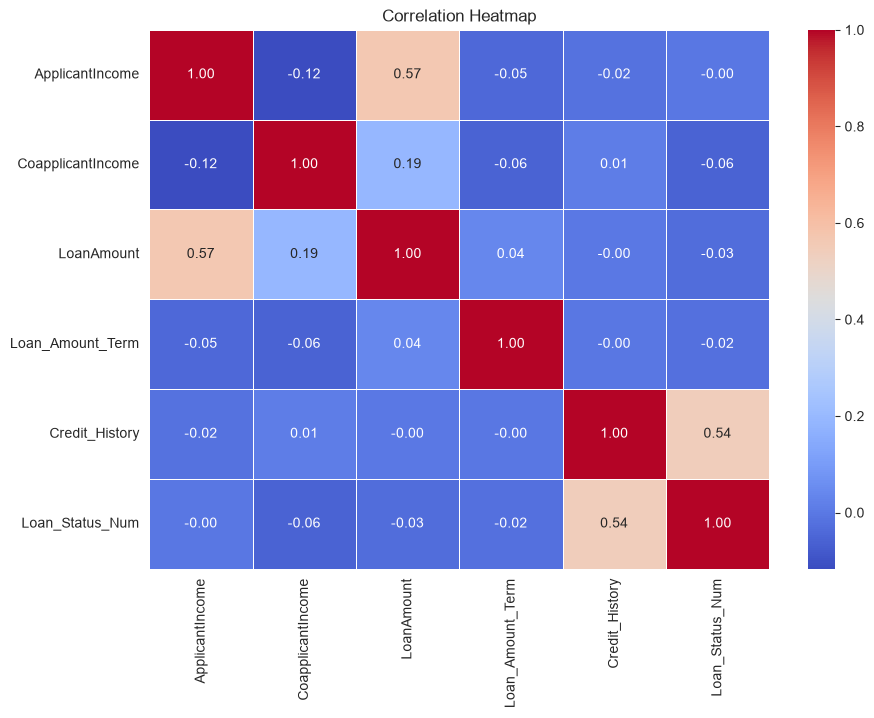

In [13]:
# Convert Loan Status to numeric for correlation
train['Loan_Status_Num'] = train['Loan_Status'].map({'Y':1, 'N':0})

plt.figure(figsize=(10,7))
corr= train[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status_Num']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_6092\1298067119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Loan_Status', y=col, palette='Set2')


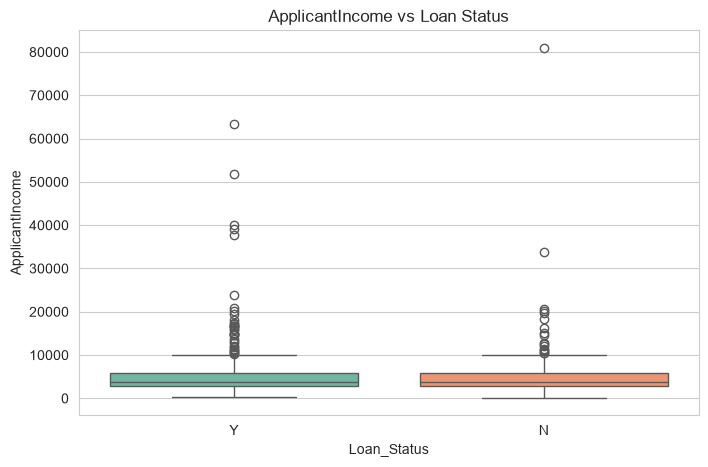

C:\Users\HP\AppData\Local\Temp\ipykernel_6092\1298067119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Loan_Status', y=col, palette='Set2')


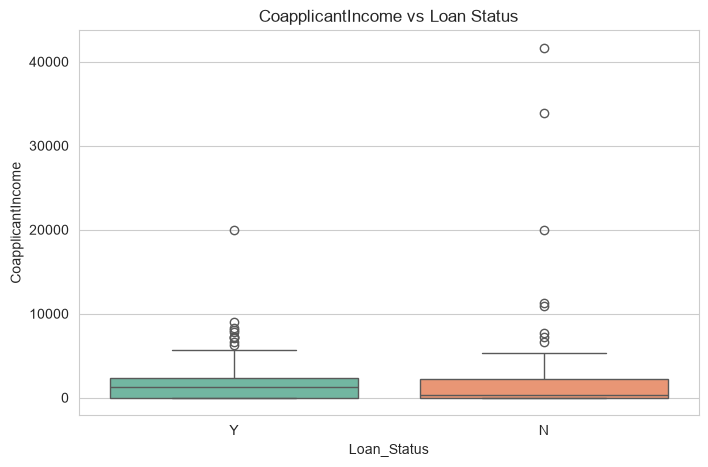

C:\Users\HP\AppData\Local\Temp\ipykernel_6092\1298067119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Loan_Status', y=col, palette='Set2')


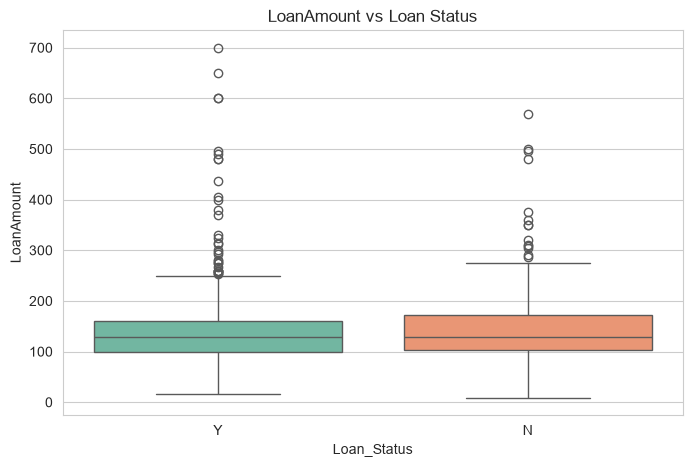

In [14]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=train, x='Loan_Status', y=col, palette='Set2')
    plt.title(f'{col} vs Loan Status')
    plt.show()

### Key Insights From EDA
1. **Credit History* is the strongest predictor - Applicants with credit history = 1 have a much higher chance of approval.
2. **Property Area: Semiurban areas show higher approval rates compared to Urban and Rural.
3. **Married applicants tend to have slighly higher apprval rates than non-married.
4. **Education: Graduates have higher approval rates than non-graduates.
5. ApplicantIncome and LoanAmount show some differences but also contain outliers.
6. The target variable is imbalanced (more approved loans than rejected).

